In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, TimeDistributed, 
                                      LSTM, Dense, Dropout, Flatten, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

# 💡 Let's break down the new imports:
# sklearn → splits data into training/testing sets and encodes labels
# Sequential → lets us build the model layer by layer (like stacking lego blocks)
# Conv2D → detects visual patterns in each frame (edges, shapes, hand features)
# MaxPooling2D → reduces frame size after Conv2D to keep only important info
# TimeDistributed → applies the same layer to EVERY frame in the sequence
# LSTM → looks at the sequence of frames OVER TIME to understand movement
# Dense → final decision-making layers
# Dropout → randomly turns off neurons during training to prevent overfitting
# Flatten → converts 2D feature maps into a 1D list for LSTM to process
# BatchNormalization → stabilizes training by normalizing layer outputs
# to_categorical → converts labels like [0,1,2] to [[1,0,0],[0,1,0],[0,0,1]]
# EarlyStopping → stops training automatically when model stops improving
# ModelCheckpoint → saves the best version of the model during training
# pickle → saves the label encoder so we can reuse it later

print("✅ All imports successful!")

✅ All imports successful!


In [15]:
SAVE_PATH = "MP_Data"

# Reduced to 5 classes with most data
SELECTED_GESTURES = ['drink', 'go', 'help', 'yes', 'no']

sequences = []
labels    = []

print("📂 Loading data...\n")

for gesture in SELECTED_GESTURES:
    gesture_path = os.path.join(SAVE_PATH, gesture)
    files        = os.listdir(gesture_path)

    for file in files:
        filepath = os.path.join(gesture_path, file)
        sequence = np.load(filepath)
        sequences.append(sequence)
        labels.append(gesture)

    print(f"  ✅ {gesture:15s} → {len(files)} sequences loaded")

X = np.array(sequences)

print(f"\n📐 X shape: {X.shape}")
print(f"📝 Total labels: {len(labels)}")

📂 Loading data...

  ✅ drink           → 15 sequences loaded
  ✅ go              → 15 sequences loaded
  ✅ help            → 14 sequences loaded
  ✅ yes             → 12 sequences loaded
  ✅ no              → 11 sequences loaded

📐 X shape: (67, 30, 64, 64, 1)
📝 Total labels: 67


In [16]:
# Convert gesture names to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
# 💡 LabelEncoder converts text labels to numbers:
#    'bad'=0, 'drink'=1, 'eat'=2, 'friend'=3 ... etc (alphabetical order)
#    Neural networks need numbers, not text

# Convert numbers to one-hot vectors
y = to_categorical(y_encoded)
# 💡 to_categorical converts numbers to vectors:
#    0 → [1, 0, 0, 0, ...] (only position 0 is 1)
#    1 → [0, 1, 0, 0, ...] (only position 1 is 1)
#    This helps the model output a probability for EACH gesture class

print(f"📐 y shape: {y.shape}")
print(f"   Meaning: {y.shape[0]} videos, {y.shape[1]} gesture classes")
print(f"\n🏷️  Label mapping:")
for i, name in enumerate(le.classes_):
    print(f"   {i:2d} → {name}")

# Save the label encoder for later use in predictions
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
# 💡 We save the encoder so our prediction script can convert
#    numbers back to gesture names (e.g. 0 → 'bad', 3 → 'friend')
print("\n✅ Label encoder saved as label_encoder.pkl")

📐 y shape: (67, 5)
   Meaning: 67 videos, 5 gesture classes

🏷️  Label mapping:
    0 → drink
    1 → go
    2 → help
    3 → no
    4 → yes

✅ Label encoder saved as label_encoder.pkl


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Fixed seed so results are reproducible
    stratify=y_encoded  # Ensures each gesture is fairly represented in both splits
)
# 💡 Think of this like dividing exam questions:
#    80% goes to "practice questions" (training)
#    20% goes to "real exam questions" (testing)
#    stratify= makes sure every gesture class appears in both sets
#    random_state=42 means if you run this again, you get the same split

print(f"📊 Data Split Summary:")
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Testing  samples  : {X_test.shape[0]}")
print(f"   Input shape       : {X_train.shape[1:]}  (30 frames × 64×64 × 1 channel)")
print(f"   Output classes    : {y_train.shape[1]}")

📊 Data Split Summary:
   Training samples  : 53
   Testing  samples  : 14
   Input shape       : (30, 64, 64, 1)  (30 frames × 64×64 × 1 channel)
   Output classes    : 5


In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# MobileNetV2 expects RGB images of at least 32×32
# We need to convert our grayscale (64×64×1) to RGB (64×64×3)

def prepare_rgb(X):
    """
    Converts grayscale sequences to RGB by repeating the channel 3 times.
    Shape: (samples, 30, 64, 64, 1) → (samples, 30, 64, 64, 3)
    """
    return np.repeat(X, 3, axis=-1)
    # 💡 np.repeat(..., 3, axis=-1) copies the single channel 3 times
    #    So a pixel value of 0.7 becomes [0.7, 0.7, 0.7]
    #    MobileNetV2 was trained on RGB images so it needs 3 channels

X_train_rgb = prepare_rgb(X_train)
X_test_rgb  = prepare_rgb(X_test)

print(f"✅ X_train shape: {X_train_rgb.shape}")
print(f"✅ X_test  shape: {X_test_rgb.shape}")
print(f"   Expected: (samples, 30, 64, 64, 3)")

✅ X_train shape: (53, 30, 64, 64, 3)
✅ X_test  shape: (14, 30, 64, 64, 3)
   Expected: (samples, 30, 64, 64, 3)


In [19]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
SEQUENCE_LENGTH = 30
IMG_SIZE        = 64
NUM_CLASSES     = 5

# ── Step 1: Load pretrained MobileNetV2 ──────────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,    
    # 💡 include_top=False removes the final classification layer
    #    We only want the feature extraction part, not the original classifier
    weights='imagenet'    
    # 💡 Load weights learned from 1.2 million ImageNet photos
    #    This model already knows edges, textures, shapes — everything!
)
base_model.trainable = False
# 💡 FREEZE the pretrained weights — don't change them during training
#    We only want to train our new GRU layers on top
#    Like hiring an expert and only teaching them YOUR company's specific rules

# ── Step 2: Build feature extractor ──────────────────────────────────────
inp    = base_model.input                  # Input: (64, 64, 3)
out    = base_model.output                 # Output: (2, 2, 1280) feature map
pooled = tf.keras.layers.GlobalAveragePooling2D()(out)
# 💡 GlobalAveragePooling2D squashes (2,2,1280) → (1280,)
#    Takes the average of each feature map — like summarizing each feature

frame_feature_extractor = Model(inputs=inp, outputs=pooled)
# 💡 This is now our "frame reader" — given one 64×64 frame,
#    it outputs 1280 meaningful feature numbers

# ── Step 3: Build the full model ──────────────────────────────────────────
import tensorflow as tf

sequence_input = tf.keras.Input(shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3))
# 💡 Our model takes a sequence of 30 RGB frames as input

features = TimeDistributed(frame_feature_extractor)(sequence_input)
# 💡 TimeDistributed applies the feature extractor to EACH of the 30 frames
#    Output shape: (batch, 30, 1280)
#    So for each frame we now have 1280 rich feature numbers

x = GRU(128, return_sequences=False)(features)
# 💡 GRU reads the sequence of 30 feature vectors (1280 each)
#    and understands the MOVEMENT pattern across time
#    128 units is enough since features are already very rich

x = Dropout(0.5)(x)
# 💡 50% dropout to prevent overfitting

x = Dense(64, activation='relu')(x)
# 💡 One dense layer to combine GRU output

x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)
# 💡 Final layer: probability for each of 20 gestures

model = tf.keras.Model(inputs=sequence_input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15096\829001927.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 30, 64, 64, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,808,005 (10.71 MB)

 Trainable params: 550,021 (2.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("🚀 Training with Transfer Learning...\n")

history = model.fit(
    X_train_rgb, y_train,    # ← original data, no augmentation needed!
    epochs=100,
    batch_size=16,
    validation_data=(X_test_rgb, y_test),
    callbacks=[early_stop, checkpoint]
)

print(f"\n✅ Training complete!")
print(f"🏆 Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training with Transfer Learning...

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.1696 - loss: 2.0393
Epoch 1: val_accuracy improved from None to 0.07143, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 206s 18s/step - accuracy: 0.1887 - loss: 1.9982 - val_accuracy: 0.0714 - val_loss: 1.8365
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5074 - loss: 1.3693
Epoch 2: val_accuracy improved from 0.07143 to 0.14286, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 903ms/step - accuracy: 0.4151 - loss: 1.5435 - val_accuracy: 0.1429 - val_loss: 1.9616
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.4454 - loss: 1.4307
Epoch 3: val_accuracy did not improve from 0.14286
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - accuracy: 0.3962 - loss: 1.4880 - val_accuracy: 0.0714 - val_loss: 1.9434
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━

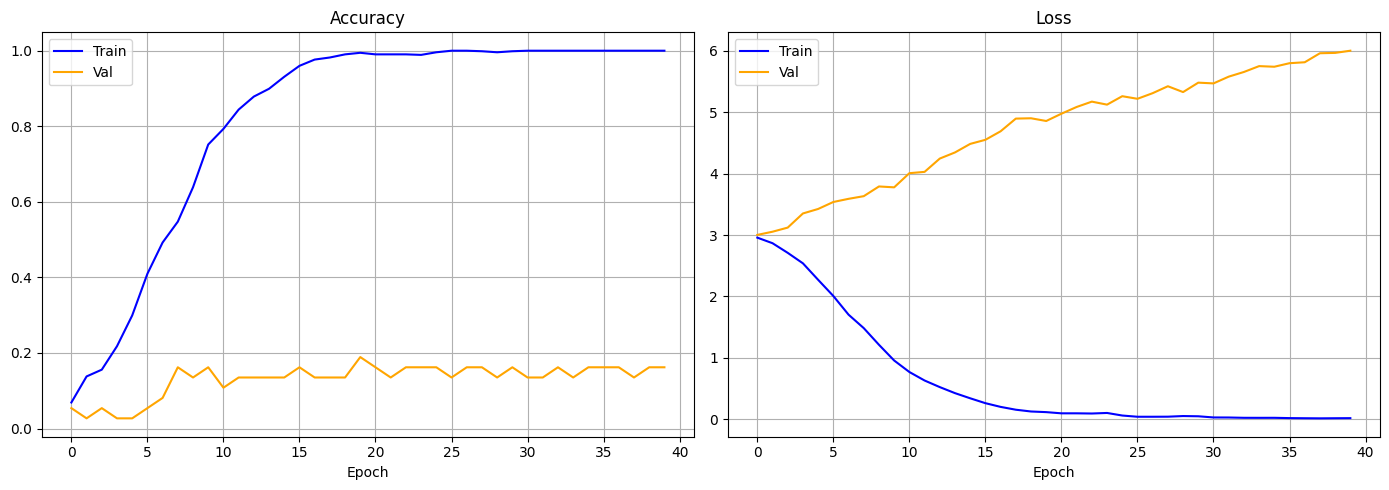

🏆 Best Validation Accuracy: 18.92%


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val',   color='orange')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train', color='blue')
ax2.plot(history.history['val_loss'], label='Val',   color='orange')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"🏆 Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")